<h3>NABATANZI GORRET SEP23/BCS/3472U/F</h3>

<h4>Importing necessary libraries</h4>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h4>importing the dataset</h4>

In [21]:
kcse_data = pd.read_csv('KCSE_Exam_Results_2006_to_2010.csv')
kcse_data

,Year,District code,District Name,County,School Code,KNEC Code,School Name,Gender,Grade attained,Mean Grade,Frequency
0,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,A-,11,3
1,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B+,8,2
2,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B,10,4
3,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B-,9,15
4,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,C+,7,32
...,...,...,...,...,...,...,...,...,...,...,...
273862,2010,* 811,MANDERA CENTRAL,Mandera,9_00,811_00,SHEIKH ALI PRIVATE,F,E,1,1
273863,2010,* 811,MANDERA CENTRAL,Mandera,9_00,811_00,SHEIKH ALI PRIVATE,M,D+,2,1
273864,2010,* 811,MANDERA CENTRAL,Mandera,9_00,811_00,SHEIKH ALI PRIVATE,M,D,4,2
273865,2010,* 811,MANDERA CENTRAL,Mandera,9_00,811_00,SHEIKH ALI PRIVATE,M,D-,3,5


<h4>How many males and females are in the dataset</h4>

In [103]:
#Filtering only males and getting the row count
males = kcse_data[ kcse_data['Gender'] == 'M'].shape[0] 

#Filtering only females and getting the row count
females = kcse_data[kcse_data['Gender'] == 'F'].shape[0]
#we can also use the shape function kcse_data[kcse_data['Gender'] == 'M'].shape[0]

#Printing the result
print(f"There are {males} males and  {females} females")

There are 147951 males and  125916 females


<h4>Which school had the highest number of A's</h4>

In [30]:
#Filtering data to get schools with grade A attained only and Grouping by School Name and sum the Frequency
a_schools_counts = kcse_data[ kcse_data['Grade attained'] == 'A'].groupby('School Name')['Frequency'].sum().reset_index()
a_schools_counts 
#sorting the data by frequency in descending order
sorted_data = a_schools_counts.sort_values(by='Frequency',ascending=False)

#Obtainining the school name 
highest_a_school_name =sorted_data.iloc[0,0]
highest_a_school_value = sorted_data.iloc[0,1]

#printing the result
print(f"The school with the highest number of A's is {highest_a_school_name} with {highest_a_school_value} A's")

The school with the highest number of A's is ALLIANCE HIGH SCHOOL with 360 A's


In [31]:
#Or
a_counts = kcse_data[ kcse_data['Grade attained'] == 'A'].groupby('School Name')['Frequency'].sum()
name = a_counts.idxmax()
value = a_counts.max()
print(f"The school with the highest number of A's is {name} with {value} A's")

The school with the highest number of A's is ALLIANCE HIGH SCHOOL with 360 A's


<h4>Which county had the lowest number of F's</h4>

In [155]:
f_counts = kcse_data[ kcse_data['Grade attained'] == 'F'].groupby('County')['Frequency'].sum()
f_counts 
# lowest_fs_county = kcse_data[kcse_data['Grade attained'] == 'F'].groupby('County')['Frequency'].sum().idxmin()
# print(f"{lowest_fs_county}")
# name = f_counts.idxmin()

# value = f_counts.min()
print("There were no F's scored")
# print(f"The school with the lowest number of F's is {name} with {value} F's")

There were no F's scored


<h4>Which district had the highest number of B-'s on average and whats the average mark</h4>

In [82]:
b_counts = kcse_data[ kcse_data['Grade attained'] == 'B-'].groupby('District Name ')['Frequency'].mean()
# b_counts.sort_values(by='Frequency',ascending=False,inplace=True)
b_counts
name = b_counts.idxmax()
value = b_counts.max()
print(f"The district with the highest number of B-'s is {name} with {value} B-'s")

The district with the highest number of B-'s is GILGIL with 28.8 B-'s


In [62]:
kcse_data.columns

Index(['Year', 'District code', 'District Name ', 'County', 'School Code',
       'KNEC Code', 'School Name', 'Gender', 'Grade attained', 'Mean Grade',
       'Frequency'],
      dtype='object')

<h4>(e) In which year did the schools in ‘TAITA’ have the highest number of ’C’s?</h4>

In [87]:
taita_schools = kcse_data[ (kcse_data['District Name '] == 'TAITA') & (kcse_data['Grade attained'] == 'C')].groupby('Year')['Frequency'].sum()
taita_schools
highest_year = taita_schools.idxmax()
total = taita_schools.max()
print(f"The TAITA Schools had the highest number of C's in the year {highest_year} with totaling to {total}")

The TAITA Schools had the highest number of C's in the year 2009 with totaling to 384


<h4>(f) Which school had the highest number of Females that got ’A’s ? In which year was this ?</h4>

In [96]:
females_with_as = kcse_data[ (kcse_data['Gender'] == 'F') & (kcse_data['Grade attained'] == 'A')].groupby(['School Name','Year'])['Frequency'].sum().reset_index()
females_with_as.sort_values(by='Frequency',ascending=False,inplace=True)
females_with_as
name = females_with_as.iloc[0,0]
year = females_with_as.iloc[0,1]
print(f"The school that had the highest number of Females that got A's is {name} obtained in the year {year}")

The school that had the highest number of Females that got A's is LORETO HIGH SCHOOL LIMURU obtained in the year 2007


In [95]:
females_with_as = kcse_data[ (kcse_data['Gender'] == 'F') & (kcse_data['Grade attained'] == 'A')].groupby(['School Name','Year'])['Frequency'].sum()

females_with_as
name = females_with_as.idxmax()[0]
year = females_with_as.idxmax()[1]
count = females_with_as.max()
print(f"The school that had the highest number of Females that got A's is {name} obtained in the year {year} with a sum of {count}")

The school that had the highest number of Females that got A's is LORETO HIGH SCHOOL LIMURU obtained in the year 2007 with a sum of 62


<h4>(g) Plot a histogram of the average number of ’D+’s across the districts for the year 2006.</h4>

In [116]:
kcse_data[['Year','Grade attained']].head(10)

,Year,Grade attained
0,2006,A-
1,2006,B+
2,2006,B
3,2006,B-
4,2006,C+
5,2006,C
6,2006,C-
7,2006,D+
8,2006,D
9,2006,A-


In [128]:
data= kcse_data[ kcse_data['Year'] == 2006]
data

,Year,District code,District Name,County,School Code,KNEC Code,School Name,Gender,Grade attained,Mean Grade,Frequency
0,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,A-,11,3
1,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B+,8,2
2,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B,10,4
3,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,B-,9,15
4,2006,* 101,TAITA,Taita Taveta,101,101101,DR. AGGREY HIGH SCHOOL,M,C+,7,32
...,...,...,...,...,...,...,...,...,...,...,...
45962,2006,* 803,MANDERA EAST,Mandera,9_01,803_01,MANDERA PRIVATE-BORDER POINT,M,C-,5,3
45963,2006,* 803,MANDERA EAST,Mandera,9_01,803_01,MANDERA PRIVATE-BORDER POINT,M,D+,2,3
45964,2006,* 803,MANDERA EAST,Mandera,9_01,803_01,MANDERA PRIVATE-BORDER POINT,M,D,4,1
45965,2006,* 803,MANDERA EAST,Mandera,9_01,803_01,MANDERA PRIVATE-BORDER POINT,M,D-,3,1


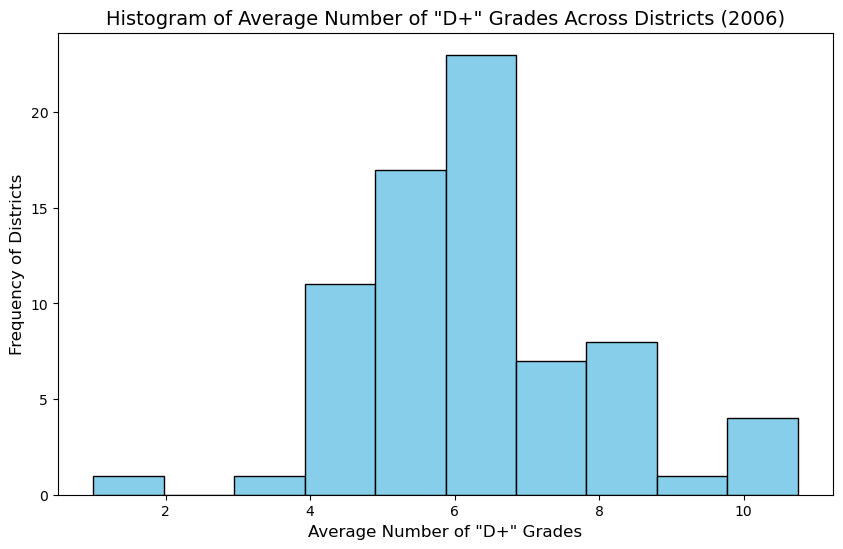

In [132]:
#Filtering data to get D+ grades for the year 2006
dplus_2006 = kcse_data[ (kcse_data['Year'] == 2006) & (kcse_data['Grade attained'] == 'D+')]
dplus_2006 

# Grouping by District namw and calculating the average frequency
average_dplus = dplus_2006.groupby('District Name ')['Frequency'].mean()

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(average_dplus, bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Average Number of "D+" Grades Across Districts (2006)', fontsize=14)
plt.xlabel('Average Number of "D+" Grades', fontsize=12)
plt.ylabel('Frequency of Districts', fontsize=12)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [140]:
#Bar chart for the schools with females who scored as for 
females_with_as = kcse_data[ (kcse_data['Gender'] == 'F') & (kcse_data['Grade attained'] == 'A')].groupby(['School Name'])['Frequency'].sum().reset_index()
females_with_as

,School Name,Frequency
0,ABUHUREIRA ACADEMY,1
1,ALLIANCE GIRLS HIGH SCHOOL,130
2,ANNESTAR PRECIOUS GIRLS SEC SCH,1
3,ARUTANI SEC SCHOOL,1
4,ASUMBI GIRLS' HIGH SCHOOL,3
...,...,...
176,THE SACRED HEART GIRLS MUKUMU,2
177,THE SECRED HEART GIRLS MUKUMU,3
178,TUMUTUMU GIRLS HIGH SCHOOL,1
179,TURBO GIRLS SEC SCHOOL,2


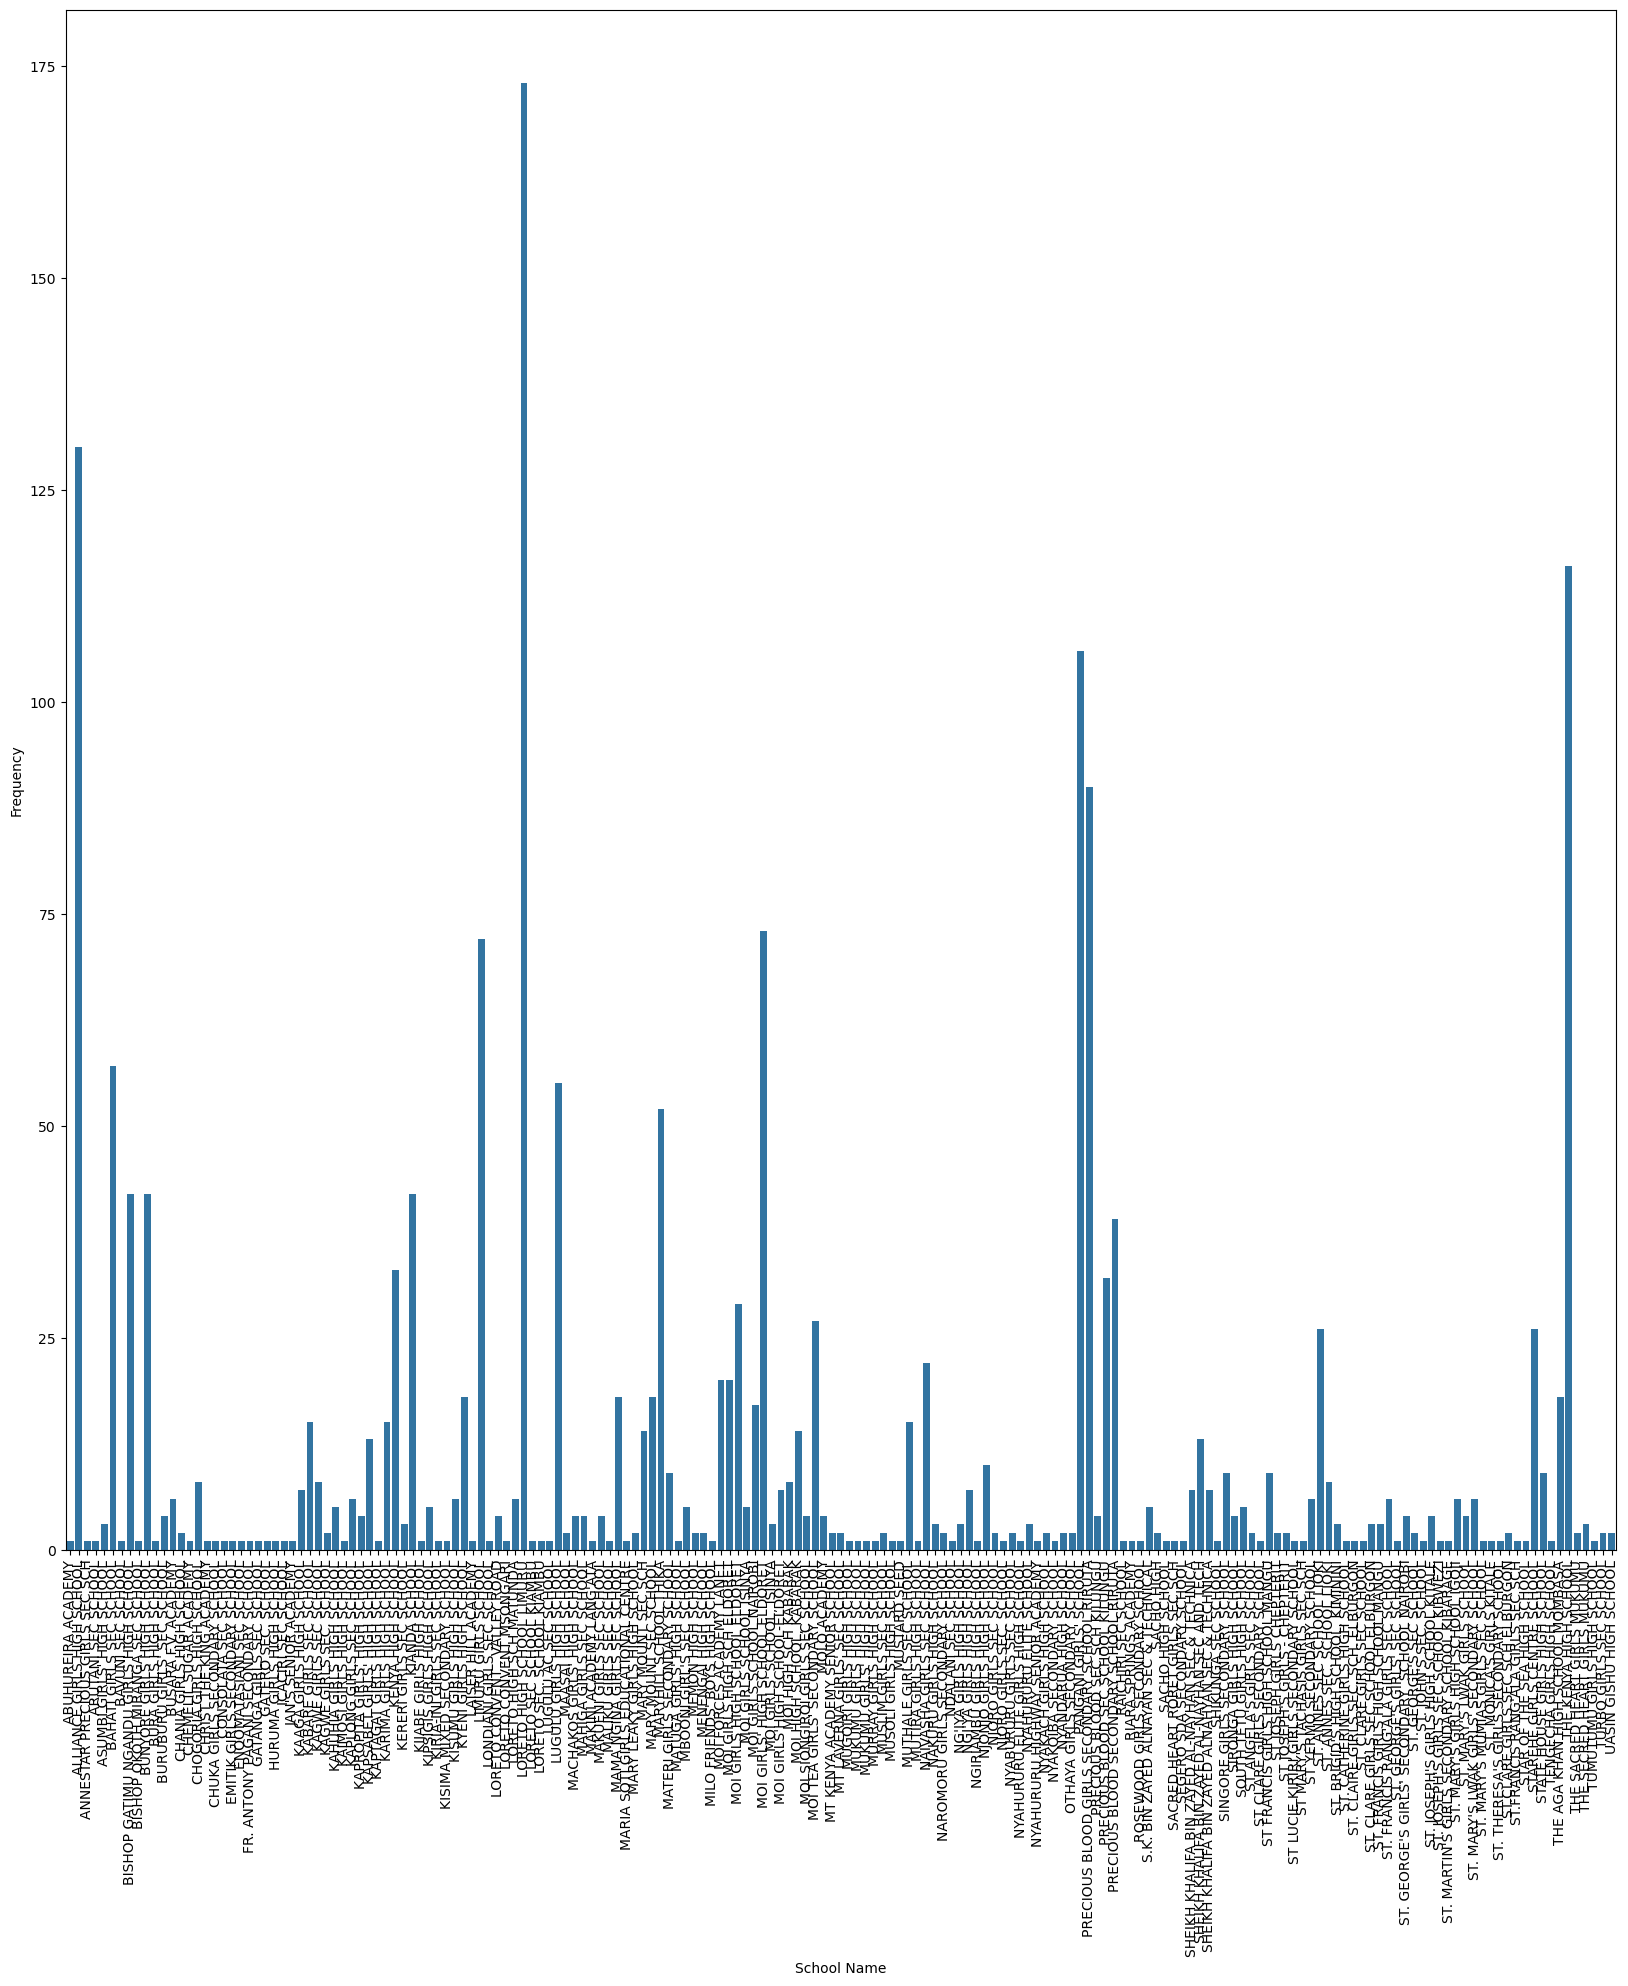

In [151]:

plt.figure(figsize=(20,20))
plt.xticks(rotation=90)
sns.barplot(x='School Name',y='Frequency',data =females_with_as)
plt.show()